# Late Delivery Risk Prediction — Exploratory Data Analysis
APL Logistics (KWE Group) — Global Supply Chain Operations


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
from pathlib import Path

file_path = Path("/workspaces/based-Late-Delivery-Risk-Prediction-in-Global-Supply-Chain-Operations/data/clean/APL_Logistics_Cleaned.csv")

# Reading the dataset
df = pd.read_csv(file_path, encoding='latin-1')

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,CortÃ©s,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,CortÃ©s,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [ ]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 180508 entries, 0 to 180507
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180508 non-null  str    
 1   Days for shipping (real)       180508 non-null  int64  
 2   Days for shipment (scheduled)  180508 non-null  int64  
 3   Benefit per order              180508 non-null  float64
 4   Sales per customer             180508 non-null  float64
 5   Delivery Status                180508 non-null  str    
 6   Late_delivery_risk             180508 non-null  int64  
 7   Category Id                    180508 non-null  int64  
 8   Category Name                  180508 non-null  str    
 9   Customer City                  180508 non-null  str    
 10  Customer Country               180508 non-null  str    
 11  Customer Fname                 180508 non-null  str    
 12  Customer Id                    180508 non

In [ ]:

dtype_df = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct_missing', ascending=False)
dtype_df


,dtype,n_unique,n_missing,pct_missing
Type,str,4,0,0.0
Days for shipping (real),int64,7,0,0.0
Days for shipment (scheduled),int64,4,0,0.0
Benefit per order,float64,21996,0,0.0
Sales per customer,float64,2927,0,0.0
Delivery Status,str,4,0,0.0
Late_delivery_risk,int64,2,0,0.0
Category Id,int64,51,0,0.0
Category Name,str,50,0,0.0
Customer City,str,562,0,0.0


In [ ]:

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing.values, y=missing.index, orient='h')
    plt.title('Missing Values by Column')
    plt.xlabel('Number of Missing Values')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


No missing values found.


In [ ]:

id_pii_cols = [
    'Customer Fname', 'Customer Lname', 'Customer Email', 'Customer Password',
    'Customer Street', 'Customer Zipcode', 'Product Description', 'Product Image',
    'Order Zipcode'
]
existing_id_pii = [c for c in id_pii_cols if c in df.columns]
print("PII / identifier columns present:", existing_id_pii)


PII / identifier columns present: ['Customer Fname', 'Customer Lname', 'Customer Street', 'Customer Zipcode']


Late_delivery_risk
1    98972
0    81536
Name: count, dtype: int64
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


/tmp/ipykernel_3324/1411194318.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Late_delivery_risk', data=df, palette='Set2')


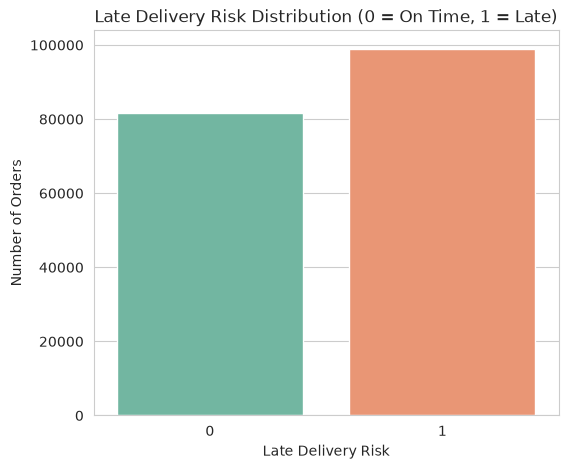

In [ ]:

target_counts = df['Late_delivery_risk'].value_counts()
target_pct = df['Late_delivery_risk'].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct.round(2))

plt.figure(figsize=(6, 5))
sns.countplot(x='Late_delivery_risk', data=df, palette='Set2')
plt.title('Late Delivery Risk Distribution (0 = On Time, 1 = Late)')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Number of Orders')
plt.show()


Delivery Status
Late delivery        98972
Advance shipping     41589
Shipping on time     32193
Shipping canceled     7754
Name: count, dtype: int64


/tmp/ipykernel_3324/1328716514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Delivery Status', data=df,


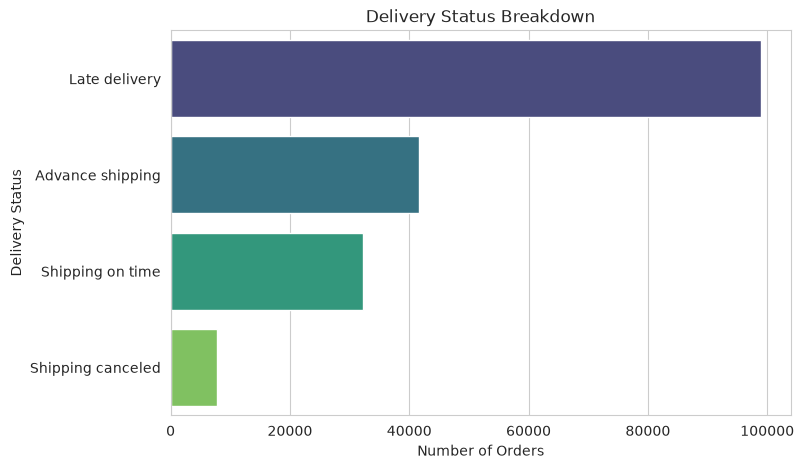

In [ ]:

print(df['Delivery Status'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y='Delivery Status', data=df,
              order=df['Delivery Status'].value_counts().index, palette='viridis')
plt.title('Delivery Status Breakdown')
plt.xlabel('Number of Orders')
plt.ylabel('Delivery Status')
plt.show()


In [ ]:

num_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Benefit per order', 'Sales per customer', 'Order Item Discount',
    'Order Item Discount Rate', 'Order Item Product Price',
    'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
    'Order Item Total', 'Order Profit Per Order', 'Product Price'
]
num_cols = [c for c in num_cols if c in df.columns]
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180508.0,3.497673,1.623743,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180508.0,2.931837,1.374457,0.00,2.00,4.00,4.00,4.00
Benefit per order,180508.0,21.971563,104.433860,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180508.0,183.101749,120.041576,7.49,104.38,163.99,247.40,1939.99
Order Item Discount,180508.0,20.663998,21.800753,0.00,5.40,14.00,29.99,500.00
Order Item Discount Rate,180508.0,0.101668,0.070416,0.00,0.04,0.10,0.16,0.25
Order Item Product Price,180508.0,141.222135,139.726957,9.99,50.00,59.99,199.99,1999.99
Order Item Profit Ratio,180508.0,0.120639,0.466806,-2.75,0.08,0.27,0.36,0.50
Order Item Quantity,180508.0,2.127706,1.453469,1.00,1.00,1.00,3.00,5.00
Sales,180508.0,203.765492,132.270786,9.99,119.98,199.92,299.95,1999.99


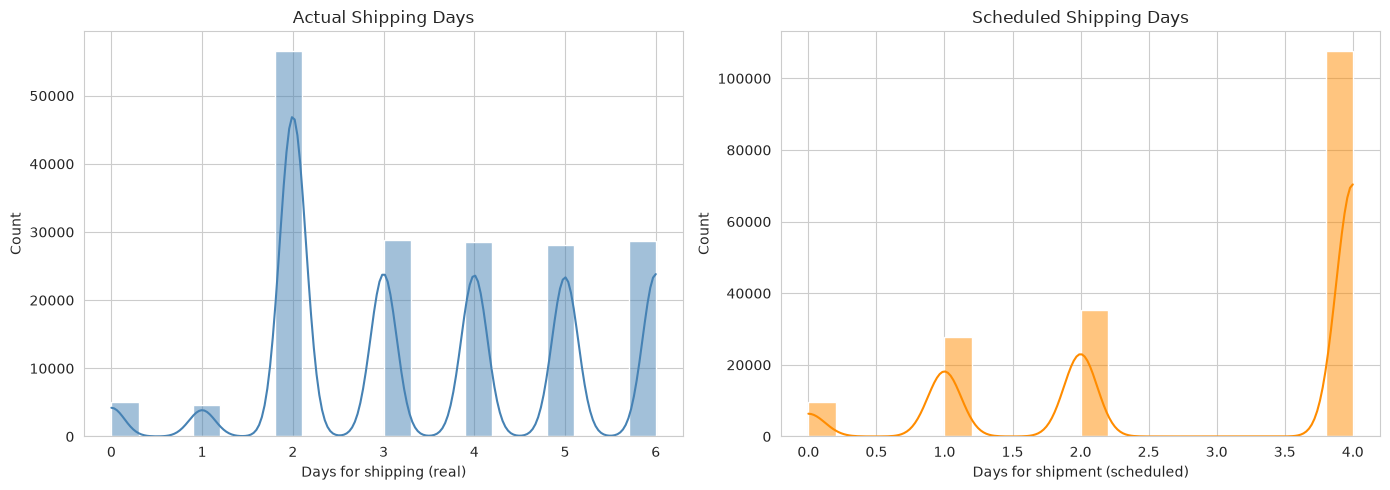

count    180508.000000
mean          0.565836
std           1.490976
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_delay_days, dtype: float64


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Days for shipping (real)'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Actual Shipping Days')

sns.histplot(df['Days for shipment (scheduled)'], bins=20, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Scheduled Shipping Days')

plt.tight_layout()
plt.show()

# Derived shipping delay (real - scheduled) — a natural sanity-check feature
df['shipping_delay_days'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
print(df['shipping_delay_days'].describe())


/tmp/ipykernel_3324/700483824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Late_delivery_risk', y='shipping_delay_days', data=df, palette='Set2')


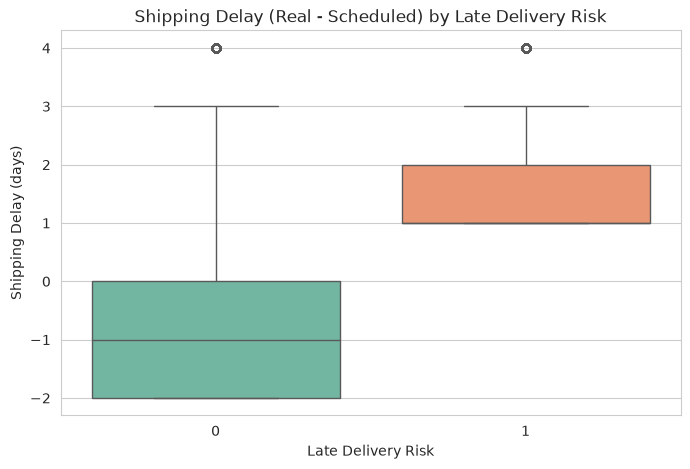

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='Late_delivery_risk', y='shipping_delay_days', data=df, palette='Set2')
plt.title('Shipping Delay (Real - Scheduled) by Late Delivery Risk')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Shipping Delay (days)')
plt.show()


Late_delivery_risk      0      1
Shipping Mode                   
First Class          4.68  95.32
Same Day            54.26  45.74
Second Class        23.37  76.63
Standard Class      61.93  38.07


<Figure size 800x500 with 0 Axes>

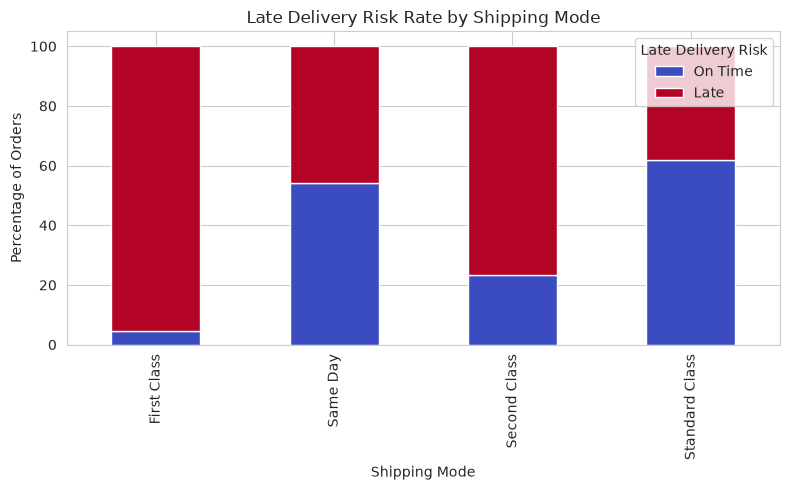

In [ ]:

mode_risk = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'], normalize='index') * 100
print(mode_risk.round(2))

plt.figure(figsize=(8, 5))
mode_risk.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 5))
plt.title('Late Delivery Risk Rate by Shipping Mode')
plt.ylabel('Percentage of Orders')
plt.xlabel('Shipping Mode')
plt.legend(title='Late Delivery Risk', labels=['On Time', 'Late'])
plt.tight_layout()
plt.show()


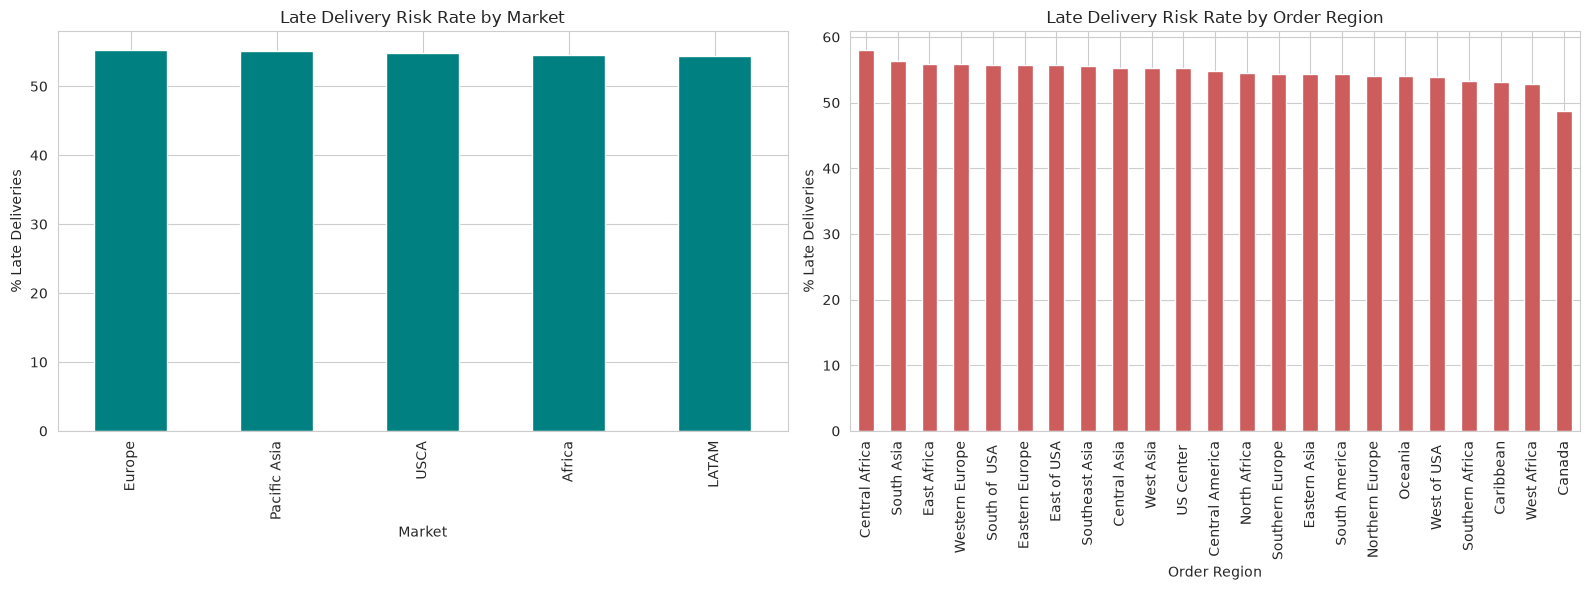

In [13]:
# Cell 14: Market and Order Region risk comparison
market_risk = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100
region_risk = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

market_risk.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Late Delivery Risk Rate by Market')
axes[0].set_ylabel('% Late Deliveries')

region_risk.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Late Delivery Risk Rate by Order Region')
axes[1].set_ylabel('% Late Deliveries')

plt.tight_layout()
plt.show()


Customer Segment
Home Office    55.07
Consumer       54.81
Corporate      54.72
Name: Late_delivery_risk, dtype: float64


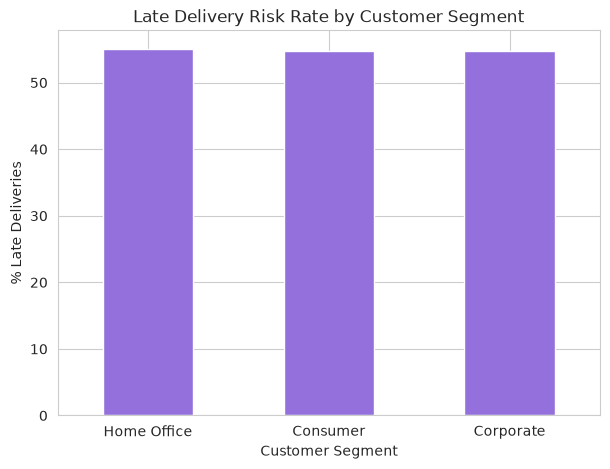

In [ ]:

segment_risk = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100
print(segment_risk.round(2))

plt.figure(figsize=(7, 5))
segment_risk.plot(kind='bar', color='mediumpurple')
plt.title('Late Delivery Risk Rate by Customer Segment')
plt.ylabel('% Late Deliveries')
plt.xticks(rotation=0)
plt.show()


In [ ]:

category_risk = (df.groupby('Category Name')['Late_delivery_risk']
                  .agg(['mean', 'count'])
                  .query('count >= 30')
                  .sort_values('mean', ascending=False))
category_risk['mean'] = (category_risk['mean'] * 100).round(2)
category_risk.head(15)


,mean,count
Category Name,,
Golf Bags & Carts,68.85,61
Lacrosse,60.06,343
Pet Supplies,58.94,492
Cameras,58.11,592
Strength Training,57.66,111
As Seen on TV!,57.35,68
Music,57.14,434
Accessories,56.97,1780
Fitness Accessories,56.96,309


/tmp/ipykernel_3324/2388741122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Late_delivery_risk', y='Order Item Quantity', data=df, palette='Set3')


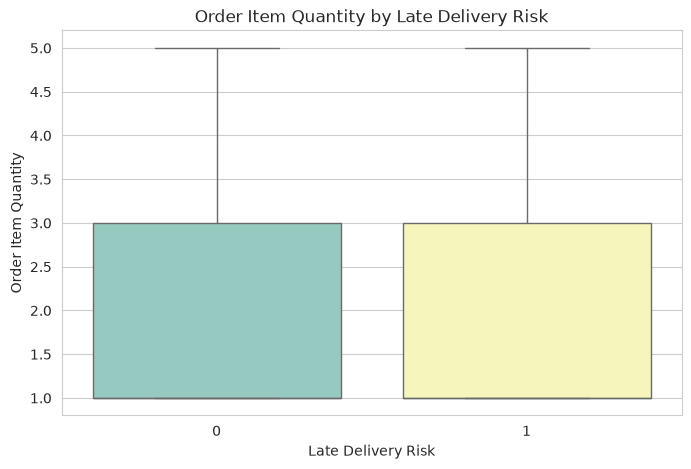

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='Late_delivery_risk', y='Order Item Quantity', data=df, palette='Set3')
plt.title('Order Item Quantity by Late Delivery Risk')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Order Item Quantity')
plt.show()


/tmp/ipykernel_3324/2547415666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Late_delivery_risk', y='Order Item Discount Rate', data=df, palette='coolwarm')


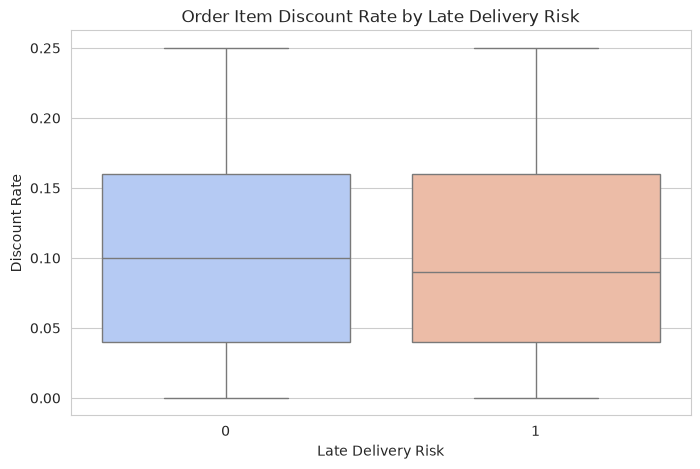

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='Late_delivery_risk', y='Order Item Discount Rate', data=df, palette='coolwarm')
plt.title('Order Item Discount Rate by Late Delivery Risk')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Discount Rate')
plt.show()


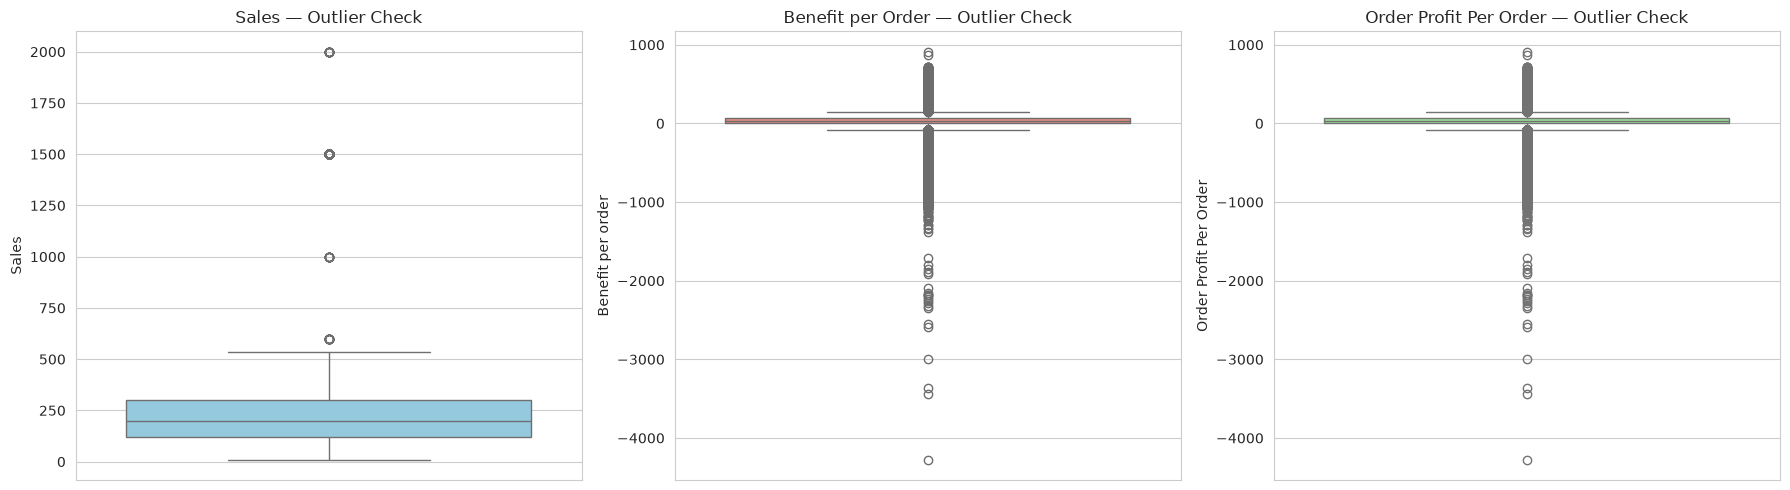

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['Sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Sales — Outlier Check')

sns.boxplot(y=df['Benefit per order'], ax=axes[1], color='salmon')
axes[1].set_title('Benefit per Order — Outlier Check')

sns.boxplot(y=df['Order Profit Per Order'], ax=axes[2], color='lightgreen')
axes[2].set_title('Order Profit Per Order — Outlier Check')

plt.tight_layout()
plt.show()


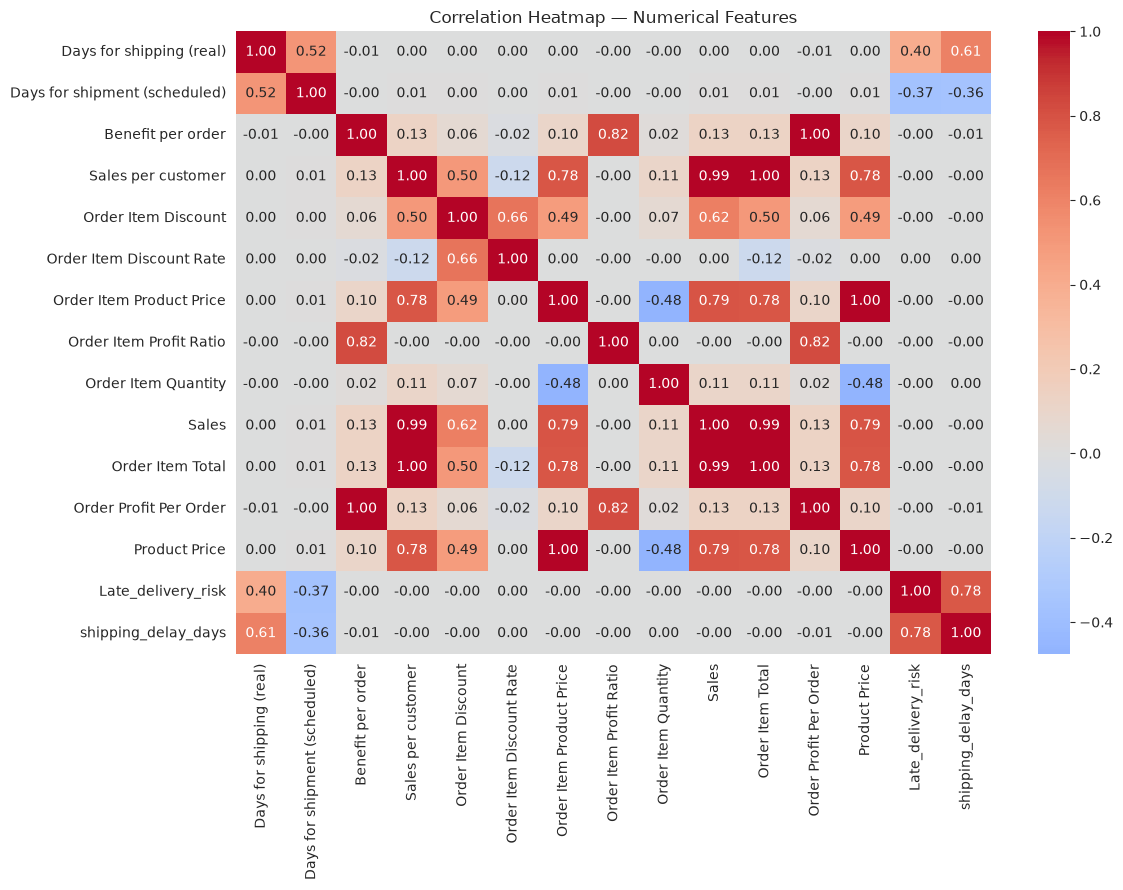

In [ ]:

corr_cols = num_cols + ['Late_delivery_risk', 'shipping_delay_days']
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(12, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()


In [ ]:

status_risk = pd.crosstab(df['Order Status'], df['Late_delivery_risk'], normalize='index') * 100
status_risk.sort_values(1, ascending=False)


Late_delivery_risk,0,1
Order Status,,
PENDING,42.098497,57.901503
PENDING_PAYMENT,42.448969,57.551031
COMPLETE,42.513490,57.486510
PAYMENT_REVIEW,42.842050,57.157950
PROCESSING,42.913889,57.086111
CLOSED,43.367659,56.632341
ON_HOLD,44.414975,55.585025
CANCELED,100.000000,0.000000
SUSPECTED_FRAUD,100.000000,0.000000


In [ ]:

country_risk = (df.groupby('Order Country')['Late_delivery_risk']
                 .agg(['mean', 'count'])
                 .query('count >= 50')
                 .sort_values('mean', ascending=False))
country_risk['mean'] = (country_risk['mean'] * 100).round(2)
country_risk.head(15)


,mean,count
Order Country,,
TurkmenistÃ¡n,69.81,53
Moldavia,69.23,78
Georgia,68.82,93
Ecuador,67.01,294
Mongolia,65.82,79
Mozambique,63.93,244
NÃ­ger,63.89,108
Somalia,63.83,141
HungrÃ­a,62.57,179


/tmp/ipykernel_3324/2489054536.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Late_delivery_risk', y='shipping_pressure_index', data=df, palette='Spectral')


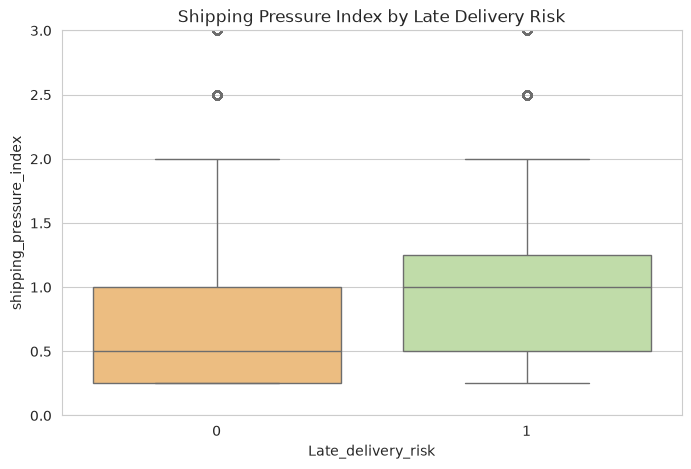

In [ ]:

df['shipping_pressure_index'] = df['Order Item Quantity'] / df['Days for shipment (scheduled)'].replace(0, np.nan)

plt.figure(figsize=(8, 5))
sns.boxplot(x='Late_delivery_risk', y='shipping_pressure_index', data=df, palette='Spectral')
plt.title('Shipping Pressure Index by Late Delivery Risk')
plt.ylim(0, df['shipping_pressure_index'].quantile(0.95))
plt.show()


In [ ]:

df['is_express'] = df['Shipping Mode'].str.contains('Express', case=False, na=False).astype(int)
express_risk = df.groupby('is_express')['Late_delivery_risk'].mean() * 100
print(express_risk.round(2))


is_express
0    54.83
Name: Late_delivery_risk, dtype: float64


In [ ]:

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"Class counts:\n{target_counts}")
print(f"\nImbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1")


Class counts:
Late_delivery_risk
1    98972
0    81536
Name: count, dtype: int64

Imbalance ratio (majority:minority): 1.21 : 1


## Key EDA Insights (fill in after running on the real dataset)

- Overall late delivery rate: *(insert value)*
- Shipping modes with highest delay rate: *(insert)*
- Regions/markets with highest delay rate: *(insert)*
- Strongest numeric correlates of `Late_delivery_risk`: *(insert)*
- Class imbalance level and recommended handling (SMOTE vs class weights): *(insert)*
- Candidate engineered features to carry into modeling: `shipping_delay_days`, `shipping_pressure_index`, `is_express`
